In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.datasets import make_classification, make_regression
from sklearn.metrics import mean_squared_error, accuracy_score

# 1. Load data
df = pd.read_csv('KC_housing_data.csv')

# HINT: Check structure first
print("\n----->head\n")
print(df.head())

print("\n----->shape\n")
print(df.shape)

print("\n----->data types/missing\n")
print(df.info())

print("\n----->numerical summary\n")
print(df.describe())



# Clean data
df = df[(df["price"] >= 10000) & (df["price"] <= 1e6)].copy()



----->head

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated          

# 1. Linear Regression: Predicting House Prices
- Visualize key features vs target price.
- Split data into train and test sets.
- Fit a Linear Regression model to predict house prices.
- Predict on test data and compute Mean Squared Error (MSE).
- Plot true vs predicted house prices.
- Interpret what the MSE says about model accuracy.


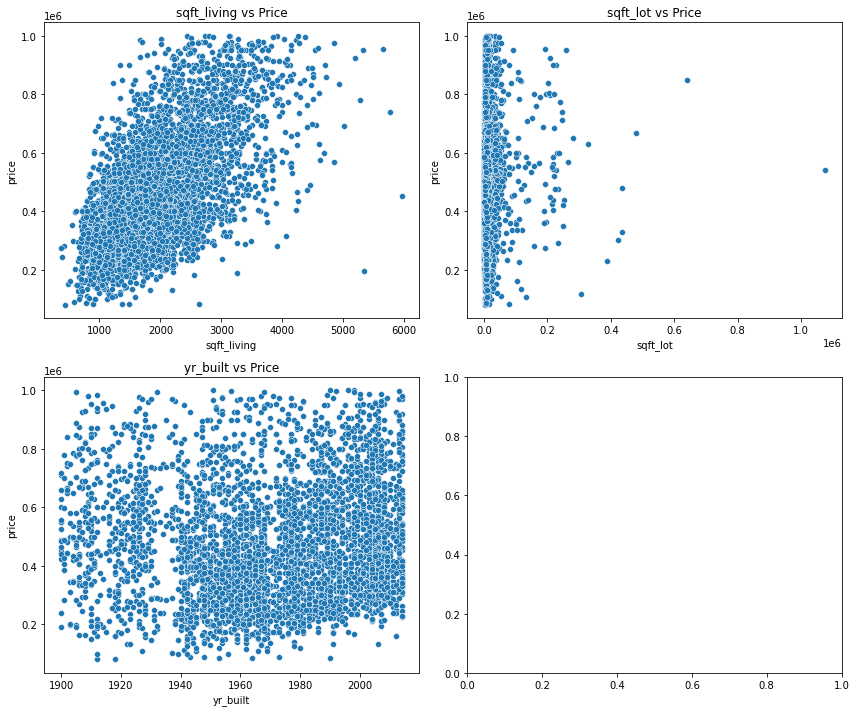

In [13]:
# Visualize key features vs target price.

key_features = ['sqft_living', 'sqft_lot', 'yr_built']

fig, ax = plt.subplots(2, 2, figsize=(12,10))

sns.scatterplot(data=df, x='sqft_living', y='price', ax=ax[0,0])
ax[0,0].set_title('sqft_living vs Price')

sns.scatterplot(data=df, x='sqft_lot', y='price', ax=ax[0,1])
ax[0,1].set_title('sqft_lot vs Price')

sns.scatterplot(data=df, x='yr_built', y='price', ax=ax[1,0])
ax[1,0].set_title('yr_built vs Price')

plt.tight_layout()
plt.show()

In [3]:
# Split data into train and test sets.

from sklearn.model_selection import train_test_split

X = df[['sqft_living']]
Y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    Y, 
    test_size=0.2,      # 20% test data
    random_state=42     # ensures reproducibility
)


In [4]:
# Fit a Linear Regression model to predict house prices.

model = LinearRegression()
model.fit(X_train, y_train)
# price=β0​+β1​⋅sqft_living
# Intercept (β₀) → Predicted price when sqft = 0
# Slope (β₁) → How much the price increases per additional square foot
print("Intercept (β0):", model.intercept_)
print("Slope (β1):", model.coef_[0])

Intercept (β0): 162433.883845622
Slope (β1): 155.79441948572423


In [5]:
# Predict on test data and compute Mean Squared Error (MSE).

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
rmse = np.sqrt(mse)
# predictions are off by about 159,000 dollars
# If the average house price is around 450,000 $, then:
# model has roughly ~30–35% average prediction error.
## Makes sense, given how the graph looks like.
# A single-variable linear regression is very simple — it cannot capture the complexity of real estate pricing.
print("Root Mean Squared Error:", rmse)


Mean Squared Error: 25218926284.609333
Root Mean Squared Error: 158804.67966848248


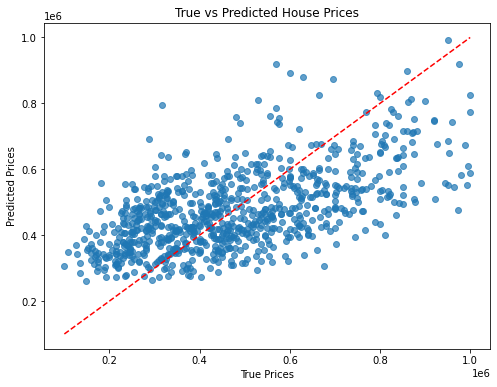

In [6]:
# Plot true vs predicted house prices.

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.title("True vs Predicted House Prices")

plt.show()

# Points close to the red line → good predictions
# Points far away → large errors

# Expensive houses often underestimated
# Cheap houses sometimes overestimated


- Interpret what the MSE says about model accuracy. \
Higher MSE = lower model accuracy


# 2.​ Logistic Regression: Classifying Expensive Houses
- Create a new binary target variable:
  - 1 if house price is above median price, else 0.
- Split data into train and test sets.
- Fit a Logistic Regression model to predict this binary label.
- Predict on test data and compute classification accuracy.
- Visualize confusion matrix or ROC curve.
- Discuss when logistic regression is useful compared to linear.


In [7]:
# Create a new binary target variable: 1 if house price is above median price, else 0.

median_price = df["price"].median()
print("Median price:", median_price)
df["expensive"] = (df["price"] > median_price).astype(int)
print(df["expensive"].value_counts())
# 1 → Above median
# 0 → Below median

Median price: 442950.0
1    2105
0    2105
Name: expensive, dtype: int64


In [8]:
# Split data into train and test sets.

X = df[['sqft_living']]
Y = df['expensive']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y # Ensures 50/50 in both training and test sets
)

print("Training set class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True))

Training set class distribution:
1    0.5
0    0.5
Name: expensive, dtype: float64

Test set class distribution:
1    0.5
0    0.5
Name: expensive, dtype: float64


In [9]:
# Fit a Logistic Regression model to predict this binary label.

log_model = LogisticRegression()
log_model.fit(X_train, y_train)
# P(expensive=1∣sqft_living)

print("Intercept:", log_model.intercept_[0])
print("Coefficient:", log_model.coef_[0][0])
# Coefficient > 0 → larger houses → higher probability of being expensive
# The larger the coefficient, the stronger the influence of square footage.

Intercept: -3.313712806675889
Coefficient: 0.001687174563866996


In [10]:
# Predict on test data and compute classification accuracy.

y_pred = log_model.predict(X_test)
# Now y_pred contains 0 or 1 for each test house.

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Accuracy = fraction of correctly classified houses
# 71%


Accuracy: 0.7161520190023754


In [11]:
# Visualize confusion matrix or ROC curve.

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
# L/R: Pred 0 / Pred 1
# T/D: True 0 / True 1

# LT: correctly, not expensive: 322
# RT: predicted wrong as expensive: 99
# LB: predicted wrong as not expensive: 140
# RB: correctly, expensive: 281


[[322  99]
 [140 281]]


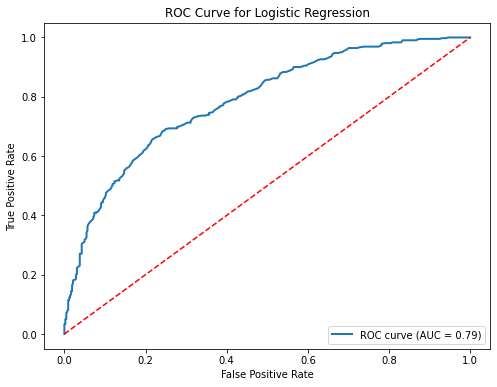

In [12]:
# Visualize confusion matrix or ROC curve.

from sklearn.metrics import roc_curve, roc_auc_score

# expensive = 1
y_prob = log_model.predict_proba(X_test)[:, 1]
# predict_proba returns two columns:
# Column 0 → probability of class 0
# Column 1 → probability of class 1 (expensive)
# [:,1] selects the probabilities for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
# fpr → False Positive Rate
# tpr → True Positive Rate
# auc → Area Under the Curve (measure of classification performance, 0.5 = random, 1 = perfect)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', linewidth=2)
plt.plot([0,1], [0,1], 'r--', linewidth=1.5)  # diagonal = random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.show()

# Curve closer to the top-left → better model
# AUC ≈ 0.5 → random guess
# AUC ≈ 1 → perfect classification



- Discuss when logistic regression is useful compared to linear.

Linear: predict continuous values -> regression problems

Logistic: predict probabilities between 0 and 1, then assigns classes based on a threshold (usually 0.5) -> classification problems


# 3.​ Comparison and Reflection
- Summarize differences in outputs, tasks, and metrics of the two models.
- Discuss real-world use cases for predicting prices vs classifying expensive
houses.
- Optionally, experiment with features and see how adding/removing
features affects both models.


#### Summarize differences in outputs, tasks, and metrics of the two models.

Outputs: \
. Linear: House price, explained by sqft_living \
. Logistic: Probability of being in category above or below median, explained by sqft_living.

Tasks: \
. The sequence was similar. The main difference was Linear vs. Logistic.

Metrics: \
. Linear: Mean Squared Error \
. Logicstic: Classification accuracy


#### Discuss real-world use cases for predicting prices vs classifying expensive

. Predicting prices: \
Estimate house price based on known features (here sqft_living). \
Sellers: Find appropriate price to put on the market. \
Buyers: Check, if house price is appropriate.

. classifying expensive: \
Recap: Price unknown. sqft_living known. Prediction, if price will be above median. \
Useless. Either price is known or price needs to be estimated. Cannot think of any useful information gained in that specific scenario. Useful would only be to know, if the price is expensive relative to sqft_living, but that was not done here.


#### Optionally, experiment with features and see how adding/removing features affects both models.

Expected to see: \
. Linear: MSE decreasing → predictions more accurate \
. Logistic: Accuracy improvement → better classification \
. Not all features will help; adding noisy or irrelevant features could reduce model performance.

Idea: \
Include a short table or plot showing: \
. RMSE of linear regression with single vs multiple features \
. Accuracy of logistic regression with single vs multiple features
